### Module Importation

In [1]:
# importing generic packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# importing train_test_split
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import plot_importance

# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


### Loading Data

In [2]:
# loading dataset
data = pd.read_csv(r"C:\Users\DT\Desktop\Practice\Data\meningitis\mening missing 12.csv")

In [3]:
# creating a dataframe
meningitis_dataset = pd.DataFrame(data)

### Data Snapshot

In [4]:
# overview of data
meningitis_dataset.head()

,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


### Data Info

In [5]:
print(meningitis_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        1200 non-null   int64  
 1   Age               1193 non-null   float64
 2   Gender            1191 non-null   object 
 3   WBC_Count         1192 non-null   float64
 4   Protein_Level     1190 non-null   float64
 5   Glucose_Level     1192 non-null   float64
 6   Pathogen_Present  1192 non-null   object 
 7   Diagnosis         1188 non-null   object 
 8   Outcome           1190 non-null   object 
 9   Hemoglobin        1181 non-null   float64
 10  WBC_Blood_Count   1190 non-null   float64
 11  Platelets         1188 non-null   float64
 12  CRP_Level         1187 non-null   float64
 13  Risk_Level        1200 non-null   object 
dtypes: float64(8), int64(1), object(5)
memory usage: 131.4+ KB
None


### Splitting Data into features and target

In [6]:
X = meningitis_dataset.drop("Risk_Level", axis=1)
y = meningitis_dataset["Risk_Level"]

### Splitting Data into Training and Testing sets

In [7]:
# splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Checking for the balance of the y_train dataset

In [8]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

Risk_Level
Low Risk         436
High Risk        412
Moderate Risk    112
Name: count, dtype: int64
Risk_Level
Low Risk         45.416667
High Risk        42.916667
Moderate Risk    11.666667
Name: proportion, dtype: float64


### Checking for the data info of the X_train training set

In [9]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 331 to 1126
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        960 non-null    int64  
 1   Age               954 non-null    float64
 2   Gender            951 non-null    object 
 3   WBC_Count         953 non-null    float64
 4   Protein_Level     951 non-null    float64
 5   Glucose_Level     954 non-null    float64
 6   Pathogen_Present  955 non-null    object 
 7   Diagnosis         951 non-null    object 
 8   Outcome           952 non-null    object 
 9   Hemoglobin        945 non-null    float64
 10  WBC_Blood_Count   953 non-null    float64
 11  Platelets         951 non-null    float64
 12  CRP_Level         950 non-null    float64
dtypes: float64(8), int64(1), object(4)
memory usage: 105.0+ KB
None


### Splitting the columns of the X_train into numerical and catergorical columns

##### Numeric Columns

In [10]:
# Convert all boolean columns to 0 and 1
X_train = X_train.astype({col: 'int64' for col in X_train.select_dtypes(include='bool').columns})

numeric_columns = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]

##### Categorical Columns

In [11]:
categorical_columns = [cat for cat in X_train.columns if X_train[cat].dtype == "object"]

##### Putting the two columns together

In [12]:
selected_columns = numeric_columns + categorical_columns

X_train_sf = X_train[selected_columns].copy()
X_test_sf = X_test[selected_columns].copy()

In [13]:
# Checking for the initial missing values in the dataset
X_train_sf.isna().sum()

Patient_ID           0
Age                  6
WBC_Count            7
Protein_Level        9
Glucose_Level        6
Hemoglobin          15
WBC_Blood_Count      7
Platelets            9
CRP_Level           10
Gender               9
Pathogen_Present     5
Diagnosis            9
Outcome              8
dtype: int64

### Checking for the number of unique values in the categorical dataset to inform decision on the type of encoding method for the categorical values

In [14]:
X_train_sf[categorical_columns].nunique()

Gender              2
Pathogen_Present    2
Diagnosis           3
Outcome             2
dtype: int64

### Implementing Machine Learning pipelines to handle missing values

In [15]:
# here we handle the missing value and also feature scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # handles missing values
    ('scaler', StandardScaler()) # handles categroical data
])

In [16]:
# this handles missing values and the categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # handles missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # handles categroical values
])

#### Initializing th preprocessor

In [17]:
# applying the transformations to the columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

### Cross Validation on the training set


In [18]:
def model_cross_val(model):
    """ 
    This function calculates the cross validation for specified models

    X: This is the X_training dataset
    y: y training dataset
    model: your model of choice
    cv = the number of cross validation
    """
    # creating pipeline using the preprocessor
    my_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Encoding the target variables which are categorical
   
    mapping = {"Low Risk": 0, "Moderate Risk": 1, "High Risk": 2}
    y_encoded = y_train.map(mapping)

    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    # cross validation using f1 due to imbalance in data
    model_score = cross_val_score(my_pipeline, X_train_sf, y_encoded, cv=cv, scoring="f1_weighted")
    return model_score.mean()


In [19]:
model_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, eval_metric='logloss', random_state=42)
}

best_model = None
best_f1 = 0

for name, model in model_dict.items():
    print(name)
    
    # Run cross-validation ONCE and save the score
    current_f1 = model_cross_val(model)
    print("CV f1:", current_f1, "\n")
    
    # Use the saved score for your comparison
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_model = name
        selected_model = model

print("Best model:", best_model)
print("Best F1 score:", best_f1)



Logistic Regression
CV f1: 0.776850735849757 

Random Forest
CV f1: 0.8106095401795382 

XGBoost
CV f1: 0.8110607130529356 

Best model: XGBoost
Best F1 score: 0.8110607130529356


### Using the selected model to train the model

In [20]:
# put model and preprocessor together
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor), # preprocessor
        ('model', selected_model) # model
    ])

### Encoding the target values

In [21]:
mapping = {"Low Risk": 0, "Moderate Risk": 1, "High Risk": 2}
y_train_encoded = y_train.map(mapping)
y_test_encoded = y_test.map(mapping)

In [22]:
pipeline.fit(X_train_sf, y_train_encoded) # fitting the pipeline to the training sets

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
# making probability predictions
y_predict_proba = pipeline.predict_proba(X_test_sf)

In [24]:
# making discrete predictions
y_predict = pipeline.predict(X_test_sf) 

In [25]:
# accuracy score
model_accuracy_score = accuracy_score(y_test_encoded, y_predict)
model_accuracy_score

0.8041666666666667

In [26]:
# classification report
report_df = pd.DataFrame(
    classification_report(
        y_test_encoded,
        y_predict,
        output_dict=True
    )
).transpose().round(3)

print("\nClassification Report")
print("=" * 50)
print(report_df)



Classification Report
              precision  recall  f1-score  support
0                 0.855   0.869     0.862  122.000
1                 0.529   0.360     0.429   25.000
2                 0.788   0.839     0.812   93.000
accuracy          0.804   0.804     0.804    0.804
macro avg         0.724   0.689     0.701  240.000
weighted avg      0.795   0.804     0.798  240.000


In [27]:
# accessing the classes of the target variable
target_names = np.array(["Low Risk", "Moderate Risk", "High Risk"])

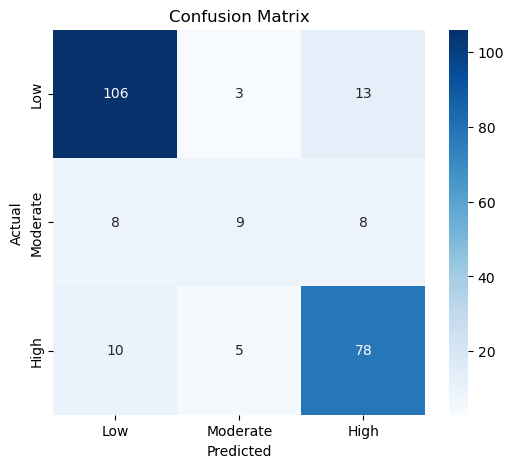

In [28]:
cm = confusion_matrix(y_test_encoded, y_predict)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low","Moderate","High"],
    yticklabels=["Low","Moderate","High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

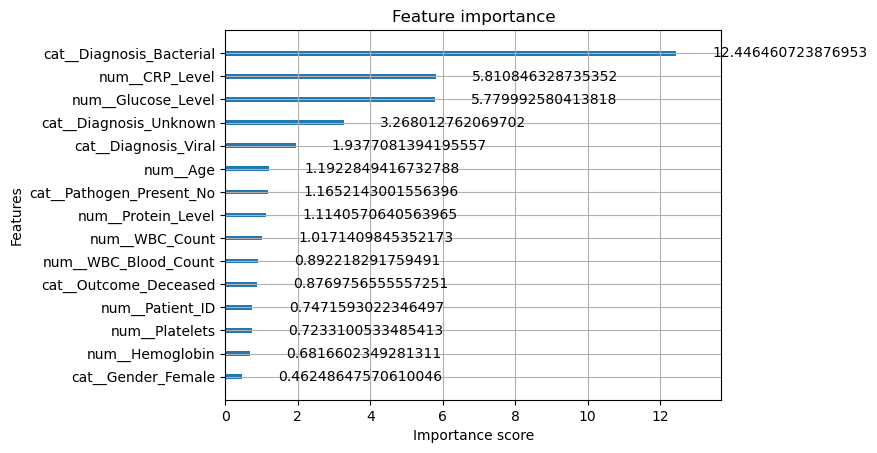

In [29]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Assign the correct 18 names and plot
model.get_booster().feature_names = list(feature_names)
plot_importance(model, importance_type='gain')
plt.show()